In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
import shutil
import zipfile
import os

shutil.copy("/content/drive/MyDrive/DLProjectData/RoCoLeDataset.zip", "/content/RoCoLeDataset.zip")
shutil.copy("/content/drive/MyDrive/DLProjectData/RoCoLeDatasetNormed.zip", "/content/RoCoLeDatasetNormed.zip")
shutil.copy("/content/drive/MyDrive/DLProjectData/CLRDataset.zip", "/content/CLRDataset.zip")
shutil.copy("/content/drive/MyDrive/DLProjectData/CLRDatasetNormed.zip", "/content/CLRDatasetNormed.zip")
shutil.copy("/content/drive/MyDrive/DLProjectData/CLRDatasetNormedAll.zip", "/content/CLRDatasetNormedAll.zip")

with zipfile.ZipFile("/content/RoCoLeDataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/RoCoLeDataset_Local")

with zipfile.ZipFile("/content/RoCoLeDatasetNormed.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/RoCoLeDatasetNormed_Local")

with zipfile.ZipFile("/content/CLRDataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/CLRDataset_Local")

with zipfile.ZipFile("/content/CLRDatasetNormed.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/CLRDatasetNormed_Local")

with zipfile.ZipFile("/content/CLRDatasetNormedAll.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/CLRDatasetNormedAll_Local")

clean_data_path = "/content/RoCoLeDataset_Local/RoCoLeDataset"
segmented_clean_data_path = "/content/RoCoLeDatasetNormed_Local/RoCoLeDatasetNormed"
messy_data_path = "/content/CLRDataset_Local/CLRDataset"
segmented_1Leaf_data_path = "/content/CLRDatasetNormed_Local/CLRDatasetNormed"
segmented_AllLeaf_data_path = "/content/CLRDatasetNormedAll_Local/CLRDatasetNormedAll"

## Two-model training comparison

This version trains two separate DenseNet201 classifiers: one on `RoCoLeDataset` and one on `RoCoLeDatasetNormed`. Both models use the same architecture, train/validation split logic, external Drive/Drive2 subsets, and Drive3 folder-level evaluation.


In [38]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import Subset
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

# Keep all random operations reproducible across both model runs.
torch.manual_seed(1234)

# Define transforms for validation and testing
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# These are the two training datasets we want to compare.
# RoCoLeDataset = original / unnormalized leaves
# RoCoLeDatasetNormed = normalized / segmented leaves
training_configs = {
    "RoCoLeDataset": clean_data_path,
    "RoCoLeDatasetNormed": segmented_clean_data_path,
}


def make_train_val_loaders(data_path, batch_size=32, test_size=0.20, random_state=42, num_workers=2):
    """Create train/validation loaders from one ImageFolder root using a stratified split."""
    full_train_dataset = datasets.ImageFolder(data_path, transform=val_transforms)
    full_val_dataset = datasets.ImageFolder(data_path, transform=val_transforms)

    targets = full_train_dataset.targets

    train_idx, val_idx = train_test_split(
        range(len(targets)),
        test_size=test_size,
        random_state=random_state,
        stratify=targets
    )

    train_dataset = Subset(full_train_dataset, train_idx)
    test_dataset = Subset(full_val_dataset, val_idx)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    return train_dataset, test_dataset, train_loader, test_loader, full_train_dataset.classes


for dataset_name, data_path in training_configs.items():
    temp_dataset = datasets.ImageFolder(data_path, transform=val_transforms)
    print(f"{dataset_name}: {len(temp_dataset)} images, classes = {temp_dataset.classes}")

RoCoLeDataset: 1393 images, classes = ['coffee___healthy', 'coffee___rust']
RoCoLeDatasetNormed: 721 images, classes = ['coffee___healthy', 'coffee___rust']


In [39]:
eval_data = datasets.ImageFolder(root=messy_data_path, transform=val_transforms)


def make_binary_target_transform(dataset):
    def binary_target_transform(label_idx):
        class_name = dataset.classes[label_idx]
        return 0 if class_name == '0' else 1
    return binary_target_transform

eval_data.target_transform = make_binary_target_transform(eval_data)

# For speed I reduced the external benchmarks to half
# total_size = len(eval_data)
# subset_size = int(0.50 * total_size)

# Use a fixed generator so both trained models are tested on the exact same external subset.
# g = torch.Generator().manual_seed(42)
# indices = torch.randperm(total_size, generator=g).tolist()
# drive_subset_data = Subset(eval_data, indices[:subset_size])

drive_test_loader = DataLoader(
    eval_data,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# print(f"Original dataset size: {total_size}")
# print(f"50% Subset size: {len(drive_subset_data)}")


In [40]:
drive2_eval_data = datasets.ImageFolder(root=segmented_1Leaf_data_path, transform=val_transforms)
drive2_eval_data.target_transform = make_binary_target_transform(drive2_eval_data)

# drive2_total_size = len(drive2_eval_data)
# drive2_subset_size = int(0.50 * drive2_total_size)

# Use a fixed generator so both trained models are tested on the exact same Drive2 subset.
# g2 = torch.Generator().manual_seed(43)
# drive2_indices = torch.randperm(drive2_total_size, generator=g2).tolist()
# drive2_subset_data = Subset(drive2_eval_data, drive2_indices[:drive2_subset_size])

drive2_test_loader = DataLoader(
    drive2_eval_data,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# print(f"Drive 2 (CLRDatasetNormed) original dataset size: {drive2_total_size}")
# print(f"Drive 2 (CLRDatasetNormed) 50% subset size: {len(drive2_subset_data)}")


In [41]:
from PIL import Image
from pathlib import Path

drive3_root = Path(segmented_AllLeaf_data_path)

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def collect_drive3_folders(root):
    plant_folders = []

    for class_dir in sorted(root.iterdir()):
        if not class_dir.is_dir():
            continue

        class_name = class_dir.name
        binary_label = 0 if class_name == "0" else 1

        for plant_dir in sorted(class_dir.iterdir()):
            if not plant_dir.is_dir():
                continue

            image_paths = [
                p for p in plant_dir.rglob("*")
                if p.suffix.lower() in image_extensions
            ]

            if len(image_paths) > 0:
                plant_folders.append({
                    "plant_dir": plant_dir,
                    "label": binary_label,
                    "image_paths": image_paths
                })

    return plant_folders



drive3_folders = collect_drive3_folders(drive3_root)


# import random

# random.seed(42)  # for reproducibility

# drive3_total_size = len(drive3_folders)
# drive3_subset_size = max(1, int(0.10 * drive3_total_size))

# drive3_folders_subset = random.sample(drive3_folders, drive3_subset_size)

# print(f"Drive3 original folder count: {drive3_total_size}")
# print(f"Drive3 10% subset folder count: {len(drive3_folders_subset)}")
# print(f"Drive3 total leaf images in subset: {sum(len(item['image_paths']) for item in drive3_folders_subset)}")

In [42]:
def evaluate_drive3_folder_level(model, drive3_folders, transform, device, batch_size=32):
    model.eval()

    correct = 0
    total = 0

    all_true_labels = []
    all_pred_labels = []

    with torch.no_grad():
        for item in drive3_folders:
            true_label = item["label"]
            image_paths = item["image_paths"]

            leaf_preds = []

            for start in range(0, len(image_paths), batch_size):
                batch_paths = image_paths[start:start + batch_size]

                images = []
                for image_path in batch_paths:
                    image = Image.open(image_path).convert("RGB")
                    image = transform(image)
                    images.append(image)

                images = torch.stack(images).to(device)

                outputs = model(images)
                preds = torch.argmax(outputs, dim=1)

                leaf_preds.extend(preds.cpu().tolist())

            folder_pred = 1 if any(pred == 1 for pred in leaf_preds) else 0

            correct += int(folder_pred == true_label)
            total += 1

            all_true_labels.append(true_label)
            all_pred_labels.append(folder_pred)

    folder_acc = correct / total

    return folder_acc, all_true_labels, all_pred_labels

In [43]:
import torch.nn as nn
from torchvision import models
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def build_densenet201_model(device):
    """Build a fresh frozen DenseNet201 with a new 2-class classifier head."""
    model = models.densenet201(weights=models.DenseNet201_Weights.DEFAULT)

    for param in model.parameters():
        param.requires_grad = False

    num_features = model.classifier.in_features
    model.classifier = nn.Linear(num_features, 2)
    model = model.to(device)

    return model


def evaluate_loader(model, dataloader, dataset_size, criterion, device):
    """Evaluate loss and accuracy on a normal image-level DataLoader."""
    model.eval()
    running_loss = 0.0
    running_corrects = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / dataset_size
    epoch_acc = running_corrects.double() / dataset_size

    return epoch_loss, epoch_acc.cpu().item()


def train_one_model(dataset_name, data_path, num_epochs=20, batch_size=32):
    """Train one model on one dataset and run all validation/external tests each epoch."""
    print("=" * 80)
    print(f"Training model on: {dataset_name}")
    print("=" * 80)

    train_dataset, test_dataset, train_loader, test_loader, classes = make_train_val_loaders(
        data_path=data_path,
        batch_size=batch_size,
        test_size=0.20,
        random_state=42,
        num_workers=2
    )

    print(f"Classes: {classes}")
    print(f"Train Size: {len(train_dataset)}, Validation Size: {len(test_dataset)}")

    model = build_densenet201_model(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [],   'val_acc': [],
        'drive_loss': [], 'drive_acc': [],
        'drive2_loss': [], 'drive2_acc': [],
        'drive3_acc': []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    print(f"Starting training for {num_epochs} epochs...")
    start_time = time.time()

    for epoch in range(num_epochs):
        print(f'\n{dataset_name} | Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        train_loss = running_loss / len(train_dataset)
        train_acc = running_corrects.double() / len(train_dataset)
        train_acc = train_acc.cpu().item()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        print(f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}')

        # Same tests as before, run for this model.
        val_loss, val_acc = evaluate_loader(model, test_loader, len(test_dataset), criterion, device)
        drive_loss, drive_acc = evaluate_loader(model, drive_test_loader, len(eval_data), criterion, device)
        drive2_loss, drive2_acc = evaluate_loader(model, drive2_test_loader, len(drive2_eval_data), criterion, device)

        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['drive_loss'].append(drive_loss)
        history['drive_acc'].append(drive_acc)
        history['drive2_loss'].append(drive2_loss)
        history['drive2_acc'].append(drive2_acc)

        print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
        print(f'Drive Loss: {drive_loss:.4f} Acc: {drive_acc:.4f}')
        print(f'Drive2 Loss: {drive2_loss:.4f} Acc: {drive2_acc:.4f}')

        drive3_acc, drive3_true, drive3_pred = evaluate_drive3_folder_level(
            model=model,
            drive3_folders=drive3_folders,
            transform=val_transforms,
            device=device
        )

        history['drive3_acc'].append(drive3_acc)
        print(f"Drive3 Folder-Level Acc: {drive3_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        scheduler.step(val_loss)

    time_elapsed = time.time() - start_time
    print(f'\n{dataset_name} training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'{dataset_name} best validation accuracy: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)

    return {
        'dataset_name': dataset_name,
        'data_path': data_path,
        'model': model,
        'best_model_wts': best_model_wts,
        'best_val_acc': best_acc,
        'history': history,
        'classes': classes,
    }

Using device: cuda:0


In [44]:
# Train both models and store their histories/results.
# You can lower num_epochs while debugging, then set it back to 20 for the final run.
num_epochs = 20

all_results = {}

for dataset_name, data_path in training_configs.items():
    all_results[dataset_name] = train_one_model(
        dataset_name=dataset_name,
        data_path=data_path,
        num_epochs=num_epochs,
        batch_size=32
    )

# Convenience variables if you want to access the models directly later.
roc_model = all_results["RoCoLeDataset"]['model']
roc_normed_model = all_results["RoCoLeDatasetNormed"]['model']


Training model on: RoCoLeDataset
Classes: ['coffee___healthy', 'coffee___rust']
Train Size: 1114, Validation Size: 279
Starting training for 20 epochs...

RoCoLeDataset | Epoch 1/20
----------
Train Loss: 0.5328 Acc: 0.7451
Val Loss: 0.4658 Acc: 0.8029
Drive Loss: 0.5322 Acc: 0.7304
Drive2 Loss: 3.2073 Acc: 0.6723
Drive3 Folder-Level Acc: 0.6723

RoCoLeDataset | Epoch 2/20
----------
Train Loss: 0.3979 Acc: 0.8285
Val Loss: 0.3764 Acc: 0.8674
Drive Loss: 0.6016 Acc: 0.6680
Drive2 Loss: 2.3485 Acc: 0.6723
Drive3 Folder-Level Acc: 0.6723

RoCoLeDataset | Epoch 3/20
----------
Train Loss: 0.3359 Acc: 0.8600
Val Loss: 0.3592 Acc: 0.8530
Drive Loss: 0.6763 Acc: 0.5820
Drive2 Loss: 2.2468 Acc: 0.6723
Drive3 Folder-Level Acc: 0.6730

RoCoLeDataset | Epoch 4/20
----------
Train Loss: 0.3172 Acc: 0.8707
Val Loss: 0.3286 Acc: 0.8817
Drive Loss: 0.5115 Acc: 0.7625
Drive2 Loss: 3.2018 Acc: 0.6723
Drive3 Folder-Level Acc: 0.6723

RoCoLeDataset | Epoch 5/20
----------
Train Loss: 0.3050 Acc: 0.8770


In [45]:
import pandas as pd

# Final-epoch comparison table across all of the same tests.
summary_rows = []
for dataset_name, result in all_results.items():
    h = result['history']
    summary_rows.append({
        "Training Dataset": dataset_name,
        "Best Val Acc": result['best_val_acc'],
        "Final Train Acc": h['train_acc'][-1],
        "Final Val Acc": h['val_acc'][-1],
        "Final Drive Acc": h['drive_acc'][-1],
        "Final Drive2 Acc": h['drive2_acc'][-1],
        "Final Drive3 Folder Acc": h['drive3_acc'][-1],
        "Final Train Loss": h['train_loss'][-1],
        "Final Val Loss": h['val_loss'][-1],
        "Final Drive Loss": h['drive_loss'][-1],
        "Final Drive2 Loss": h['drive2_loss'][-1],
    })

results_summary = pd.DataFrame(summary_rows)
results_summary


,Training Dataset,Best Val Acc,Final Train Acc,Final Val Acc,Final Drive Acc,Final Drive2 Acc,Final Drive3 Folder Acc,Final Train Loss,Final Val Loss,Final Drive Loss,Final Drive2 Loss
0,RoCoLeDataset,0.899642,0.928187,0.888889,0.728245,0.672254,0.672254,0.203923,0.299960,0.556312,3.407107
1,RoCoLeDatasetNormed,0.586207,0.791667,0.551724,0.547076,0.583809,0.353067,0.489569,0.689356,0.771316,0.689584


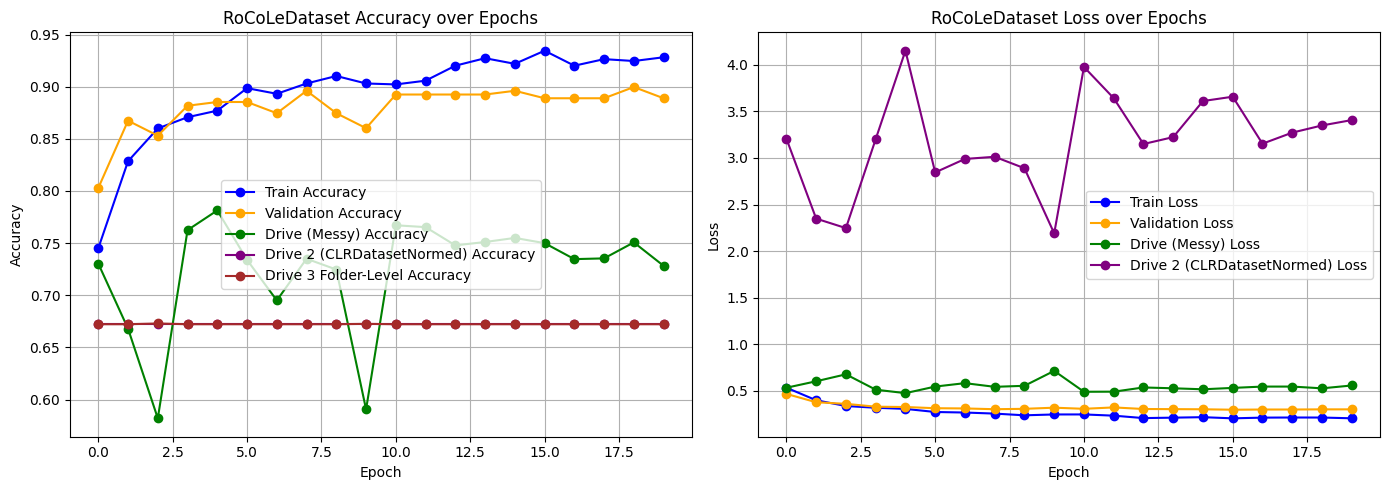

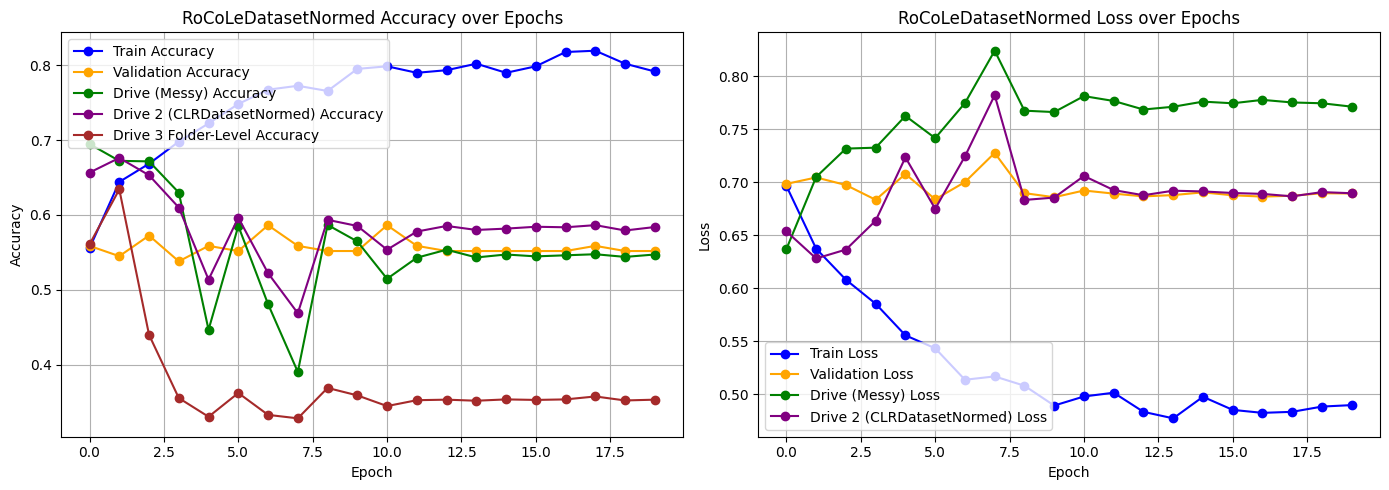

In [46]:
import matplotlib.pyplot as plt

for dataset_name, result in all_results.items():
    history = result["history"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy plot
    ax1.plot(history["train_acc"], label="Train Accuracy", color="blue", marker="o")
    ax1.plot(history["val_acc"], label="Validation Accuracy", color="orange", marker="o")
    ax1.plot(history["drive_acc"], label="Drive (Messy) Accuracy", color="green", marker="o")
    ax1.plot(history["drive2_acc"], label="Drive 2 (CLRDatasetNormed) Accuracy", color="purple", marker="o")
    ax1.plot(history["drive3_acc"], label="Drive 3 Folder-Level Accuracy", color="brown", marker="o")

    ax1.set_title(f"{dataset_name} Accuracy over Epochs")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True)

    # Loss plot
    ax2.plot(history["train_loss"], label="Train Loss", color="blue", marker="o")
    ax2.plot(history["val_loss"], label="Validation Loss", color="orange", marker="o")
    ax2.plot(history["drive_loss"], label="Drive (Messy) Loss", color="green", marker="o")
    ax2.plot(history["drive2_loss"], label="Drive 2 (CLRDatasetNormed) Loss", color="purple", marker="o")

    ax2.set_title(f"{dataset_name} Loss over Epochs")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()
